# Machine Learning Tutorial 11 - Random Forest
__Random forest__ is a popular __regression and classification algorithm.__ In this tutorial, we will see how it works for classification problem in machine learning. It uses __decision tree__ underneath and forms multiple trees and eventually takes majority vote out of it. We will go over some theory first and then solve __digits classification__ problem using __sklearn RandomForestClassifier.__ In the end we have an exercise for you to solve.

Code: https://github.com/codebasics/py/blob/master/ML/11_random_forest/11_random_forest.ipynb

Credit: https://www.youtube.com/watch?v=ok2s1vV9XW0&list=PLeo1K3hjS3uvCeTYTeyfe0-rN5r8zn9rw&index=13

#### Owner: codebasics

### Complex decision tree

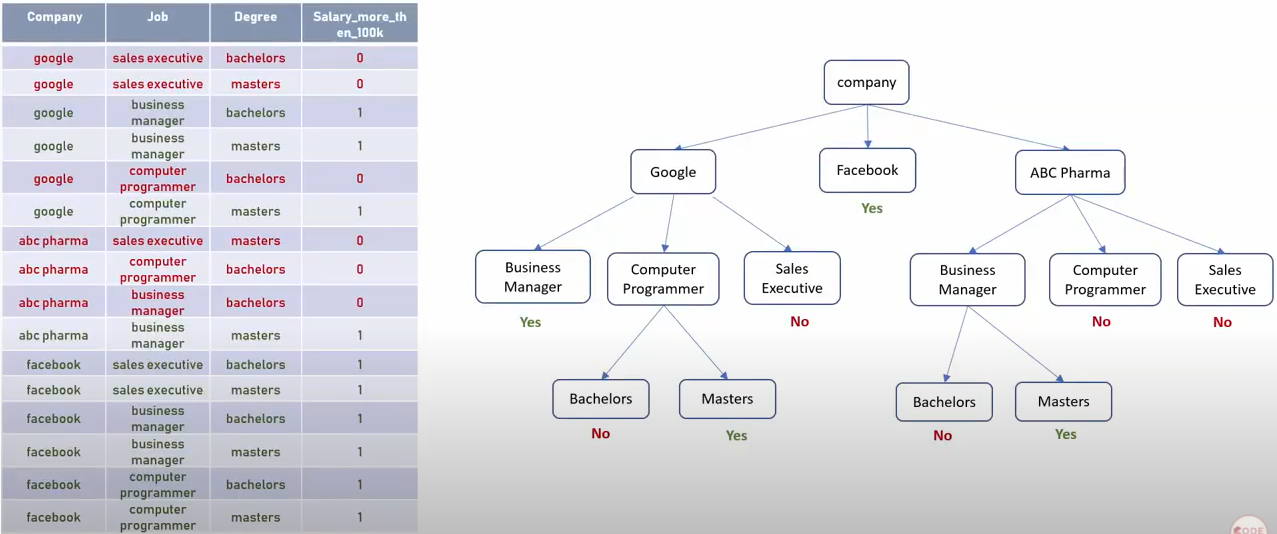

### Complex decision tree, break into multiple decision trees [random sampling], called as <font color='maroon'>Random Forest</font>

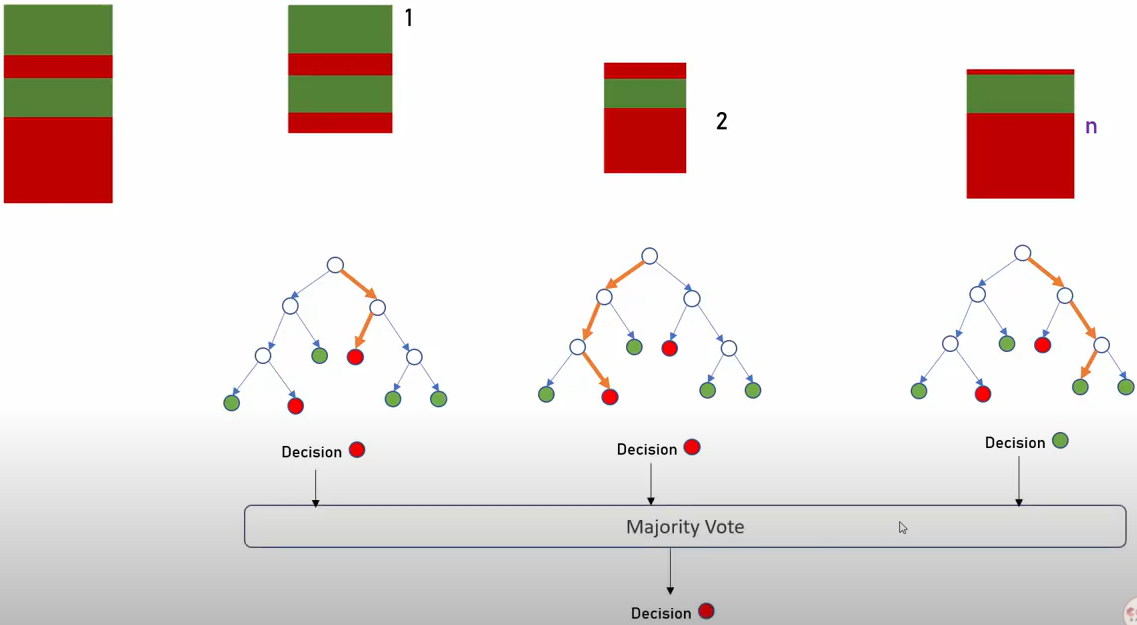

Now, __train__ all these __trees__ and then __predict__, so all will come up with different decision. Finally take the majority of all decision and come to the __final conclusion decision.__ Simply, this is called as __random forest algorithm.__

# <font color='blue'>Indentify hand written digits recognition using the dataset of sklearn</font>
## <font color='gray'>means need to classify, what is this digit?</font> <font color='green'>Using Random Forest Classifier</font>

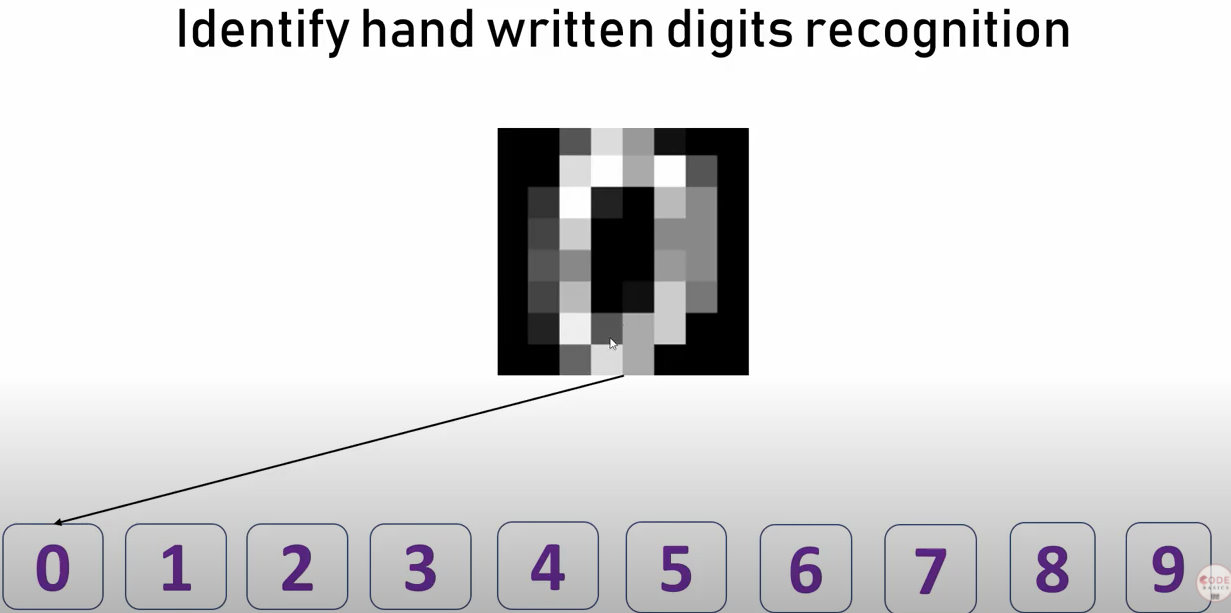

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits # digits dataset
digits = load_digits()
print(digits.data.shape) # rows x columns
#digits.feature_names # 8x8 pixel name like pixel_0_0 to pixel_7_7 
#digits.target_names # array of numbers from 0 to 9
#dump = digits.target
#dump.tofile('digits.csv') this is wrong... giving some gibberish characters, 
#ideally want to put in csv, in order to understand how many digitis character of each number
digits

(1797, 64)


{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

## digit data set information
### each digit character is hand written and width of 64 with 8 x 8 image

In [88]:
dir(digits) # properties of the dataset

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

<Figure size 432x288 with 0 Axes>

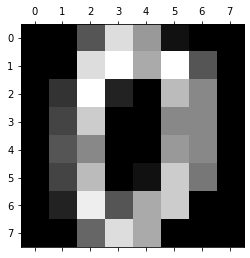

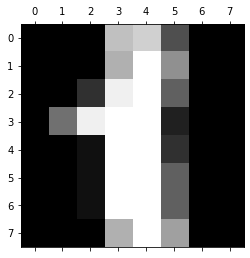

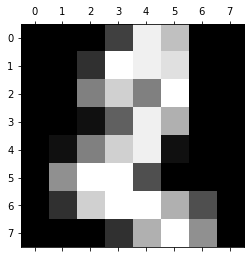

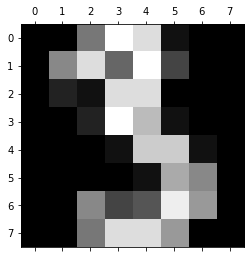

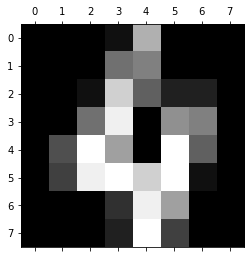

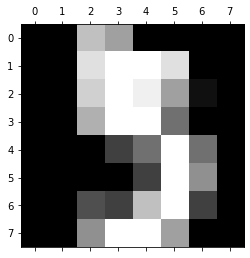

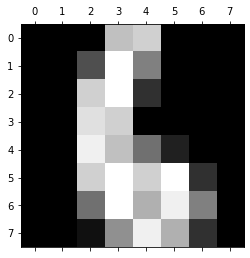

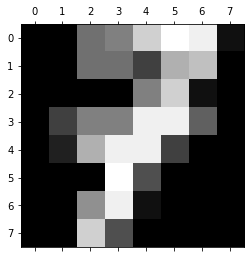

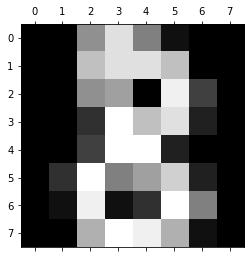

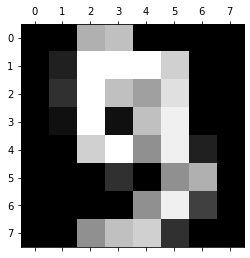

In [89]:
%matplotlib inline 
# displayed just below the cell where your plotting commands are written, 
# will not affect the previous plot, which means it separates different plots.

plt.gray()
for i in range(10):  # here, in range loop 'i' is beginning from 0th (zero-th)
    plt.matshow(digits.images[i])
    
#plt.matshow(digits.images[4])
#plt.show()
#print(digits.images[7].shape)

In [90]:
df = pd.DataFrame(digits.data, columns=digits.feature_names) # dataframe size is : 1797 rows × 64 columns
df.head()
# here, each sample is an array of 64 integers and they mapped to 'target' variable
#l=len(digits.target) # 1797 : size of an array
#l
digits.target # number of rows with all (0 to 9) character variables 

array([0, 1, 2, ..., 8, 9, 8])

In [91]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [92]:
digits.target_names

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Indentifying the character by using the __'target'__ and since __'pandas'__ include target in matrix so at last need to remove it.

This way appending the __"target"__ into __"pandas's"__ data frame

Each row in matrix is mapped to specific __target numeric character.__

In [93]:
df['target'] = digits.target # "target" appending into "pandas's" data frame
df[0:2] # will represent only two rows
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


#### Train and the model and prediction

In [94]:
X = df.drop('target',axis='columns')
y = df.target

In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
len(X_train)

1437

In [96]:
len(X_test)

360

In [97]:
len(X_train) + len(X_test)

1797

Use __Random Forest Algorithm__ to implement or deploy the data. Here, we are using multiple algorithm to get the final decision, that's why named as __ensemble__

In [98]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=20) # here, it means we are going to use 20 random trees to get the final conclusion
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20)

In [99]:
model.score(X_test, y_test)

0.95

In [100]:
y_predicted = model.predict(X_test)

#### Confusion Matrix
this is used to analysis the outcome result of our __digit data images__, in matrix form

In [101]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted) # confusion_matrix(y_true,y_pred,...
cm

array([[30,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 33,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1, 37,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 43,  0,  0,  0,  2,  1,  2],
       [ 0,  0,  0,  0, 32,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0, 34,  0,  0,  0,  3],
       [ 0,  0,  0,  0,  0,  1, 40,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 39,  0,  0],
       [ 0,  1,  1,  0,  0,  0,  0,  1, 29,  0],
       [ 0,  2,  0,  1,  1,  0,  0,  0,  0, 25]], dtype=int64)

### Re-present in a graphical way of format using <font color='maroon'>'seaborn'</font> library

Text(69.0, 0.5, 'Truth')

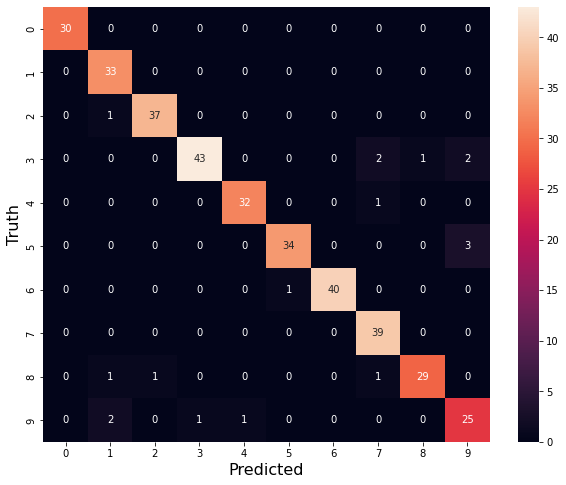

In [102]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize=(10, 8))
sb.heatmap(cm, annot=True)
plt.xlabel('Predicted', fontsize=16)
plt.ylabel('Truth', fontsize=16)